In [1]:
import os
import sys

import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from sklearnex import patch_sklearn
patch_sklearn()

import config as cfg
from sklearn.cluster import KMeans

import joblib

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [2]:
# Setup

## Change this 
image_path = r"Day Time\daylight-30m-per-pixel"
##
whole_dir = os.path.join(cfg.IMG_FULL_DATA_PATH, image_path)
ext = ".tiff"

In [3]:
for file in os.listdir(whole_dir):
    print(file)

.DS_Store
2016
2017
2018
2019
2020


In [4]:
def image_processing(dir_path, img_path, year, month):
    # Create models folder inside dir_path if it doesn't exist

    if not os.path.exists(os.path.join(dir_path, 'models')):
        os.makedirs(os.path.join(dir_path, 'models'))
    
    full_img = cv.imread(img_path)
    full_img = cv.cvtColor(full_img, cv.COLOR_BGR2RGB)

    full_pixels = pd.DataFrame(full_img.reshape(full_img.shape[0] * full_img.shape[1], 3), columns=['R', 'G', 'B'])

    inertias = []
    n = 7
    for i in range(2, n):
        temp = full_pixels.copy()
        for col in temp.columns:
            temp[col] = temp[col] / 255.
        model = KMeans(n_clusters=i)
        model.fit(temp)
        temp['clusters'] = model.predict(temp)
        inertias.append(model.inertia_)
        print(f'Done Clustering {i} clusters...')
    print("Done training")
    temp = full_pixels.copy()
    for col in temp.columns:
        temp[col] = temp[col] / 255.
    model = KMeans(n_clusters=7)
    model.fit(temp)
    temp['clusters'] = model.predict(temp)
    inertias.append(model.inertia_)
    print(f'Done Clustering {i} clusters...')

    colors = temp.groupby('clusters').mean()
    # Saving Clustering Method
    joblib.dump(model, os.path.join(dir_path, 'models', f'cluster_{year}_{month}.joblib'))

In [5]:
for dir in os.listdir(whole_dir):
    # print dir
    dir_path = os.path.join(whole_dir, dir)
    year = dir_path[-4:]
    if dir_path == os.path.join(whole_dir, ".DS_Store"):
        continue
    month = 1
    for file in os.listdir(dir_path):
        if file.endswith(ext):
            img_path = os.path.join(dir_path, file)
            image_processing(dir_path, img_path, year, month)
            month += 1
    print(f"Done with {dir}")

Done Clustering 2 clusters...
Done Clustering 3 clusters...
Done Clustering 4 clusters...


KeyboardInterrupt: 

In [12]:
# Open joblib model
# model_path = *insert model path here*
model = joblib.load(os.path.join(model_path, 'models', 'cluster_2016_1.joblib'))

In [13]:
model

KMeans(n_clusters=2)

In [14]:
# Inspect model clusters
model.cluster_centers_

array([[0.13386138, 0.18035321, 0.11948441],
       [0.70656848, 0.712593  , 0.68693816]])

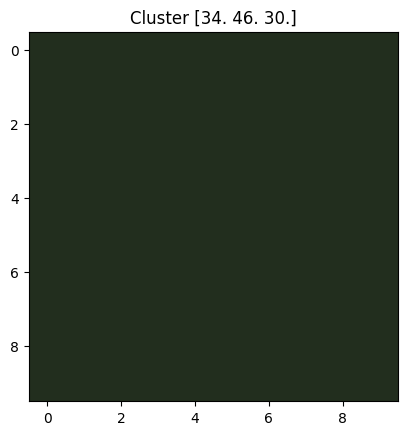

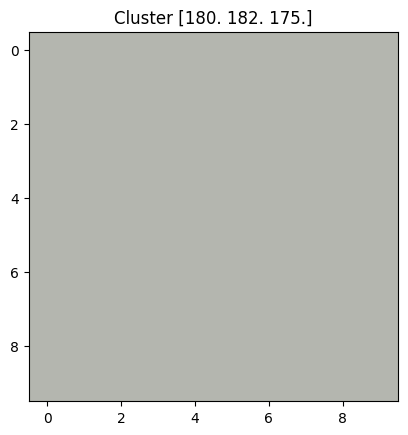

In [19]:
colors = pd.DataFrame(model.cluster_centers_, columns=['R', 'G', 'B'])

for i, colorvals in colors.iterrows():
    pixel = np.round(colorvals.values * 255.)
    color_img = np.array([pixel for i in range(0, 100)]).reshape(10, 10, 3).astype(int)
    plt.imshow(color_img)
    plt.title(f"Cluster {pixel}")
    plt.show()